In [ ]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from pydantic import BaseModel, Field



import os

# Set API key manually
os.environ["ANTHROPIC_API_KEY"] = ""

In [2]:
llm = ChatAnthropic(
    model="claude-3-5-sonnet-latest",
    api_key=os.getenv("ANTHROPIC_API_KEY"),  # Use the environment variable
    temperature=0.2,
    max_tokens=1024
)


# use output srructure in LLM 

In [3]:
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, justification="Why this query is relevant to the user's request."
    )

In [4]:
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("how to build an agent with lanchain")
print(output.search_query)
print(output.justification)

how to build an agent using langchain tutorial guide
The user wants to learn about building agents with LangChain, so searching for tutorials and guides will provide helpful information on getting started.


# Tool use LLM


In [5]:
# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
# msg.tool_calls
msg

AIMessage(content=[{'text': "I'll help you multiply 2 and 3 using the multiply function.", 'type': 'text'}, {'id': 'toolu_01CuHEgw8mA4iKiGfV2ihxQ4', 'input': {'a': 2, 'b': 3}, 'name': 'multiply', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01AxSJhaf7dj4XaQ8AsYpQsN', 'model': 'claude-3-5-sonnet-20241022', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 383, 'output_tokens': 86}}, id='run-c764d321-8b79-4b3b-9939-6d5d65bda2e7-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'toolu_01CuHEgw8mA4iKiGfV2ihxQ4', 'type': 'tool_call'}], usage_metadata={'input_tokens': 383, 'output_tokens': 86, 'total_tokens': 469, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}})

# Prompt chaining


In [6]:
from typing_extensions import TypedDict

# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

In [8]:
# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}

def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding dark humor: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""

    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}

# Conditional edge function to check if the joke has a punchline
def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

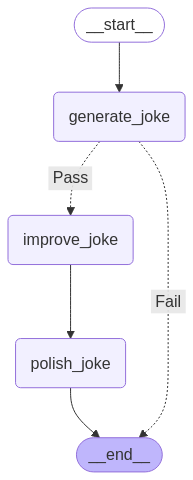

In [9]:

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Pass": "improve_joke", "Fail": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

In [10]:
state = chain.invoke({"topic": "indian street food"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Joke failed quality gate - no punchline detected!")

Initial joke:
Here's a short joke about Indian street food:

Why did the pani puri vendor go out of business?

Because he couldn't keep his fillings to himself! (He spilled the tea/secrets)

Alternative:

What did the samosa say to the chutney?
"You're the only one who dips me when I'm down!"

--- --- ---

Improved joke:
Here's a darker version of the pani puri joke:

Why did the pani puri vendor go out of business?

Because his customers kept dying from his "special" water! (And he still couldn't keep that secret to himself)

Alternative darker samosa joke:

What did the depressed samosa say to the chutney?
"You're the only one who dips me when I'm down... unlike my family who disowned me for being too spicy for their traditional values!"

Note: These maintain food humor while adding darker elements without being too extreme.

--- --- ---

Final joke:
Here's a playful twist that keeps things lighthearted:

Why did the pani puri vendor go out of business?

Because his "special" water t

# Paralel 

In [12]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [13]:
# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a very short story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a very short poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

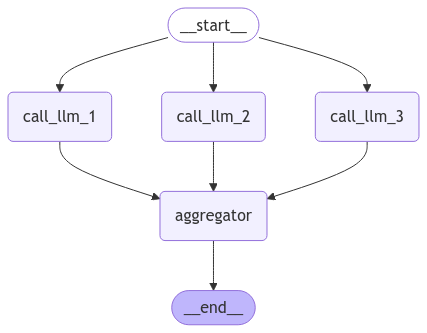

In [14]:
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)


parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [15]:
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Here's a story, joke, and poem about cats!

STORY:
Here's a very short story about cats:

The Window Watchers

Every morning, Max and Luna perched on the windowsill, their tails twitching in unison as they watched the birds flutter around the garden. The two cats, one orange and one gray, were inseparable siblings who considered this their most important daily duty.

One day, a blue jay landed particularly close to the window, causing both cats to press their paws against the glass in excitement. Their synchronized meowing caught the bird's attention, and it cocked its head curiously at them before flying away.

Luna looked at Max and gave a disappointed mrrow. Max responded by grooming his sister's ear, as if to say, "There's always tomorrow." They settled back into their usual position, continuing their watch until the sun began to set, content in their simple routine together.

JOKE:
Here's a cat joke for you:

Why don't cats like online shopping?

They prefer a cat-alog!

POEM:
Her

# Routing

In [18]:
from typing_extensions import Literal

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )

# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)

In [19]:
# State
class State(TypedDict):
    input: str
    decision: str
    output: str

In [20]:
from langchain_core.messages import HumanMessage, SystemMessage

# Nodes
def llm_call_1(state: State):
    """Write a story"""

    print("Write a story")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    print("Write a joke")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    print("Write a poem")
    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}

# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

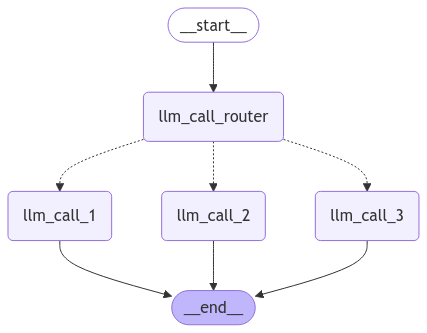

In [21]:

# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [23]:
state = router_workflow.invoke({"input": "Write me a short poem about cats"})
print(state["output"])

Write a poem
Here's a short poem about cats:

Soft paws and whiskers long,
Graceful moves like a song,
Purring gently on my lap,
Taking yet another nap.
Golden eyes that shine so bright,
Hunting shadows in the night,
Independent, proud, and free,
Perfect pets for you and me.


# Generate Evaluate 

In [27]:
class Feedback(BaseModel):
    grade: Literal["Funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.")
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.")
    
evaluator_llm = llm.with_structured_output(Feedback)    

In [28]:
class State(TypedDict):
    joke: str
    feedback: str
    topic: str
    funny_or_not: str

In [35]:
def llm_call_generator(state: State):
    """LLM generates a joke"""
    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:           
        msg = llm.invoke(f"Write a joke about {state['topic']}")

    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """Evaluate the joke and provide feedback"""
    grade = evaluator_llm.invoke(f"Grade the joke: {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

def route_joke(state: State):
    """Route the joke based on the evaluation"""
    if state["funny_or_not"] == "Funny":
        return "Accepted"
    else:
        return "Rejected + Feedback"

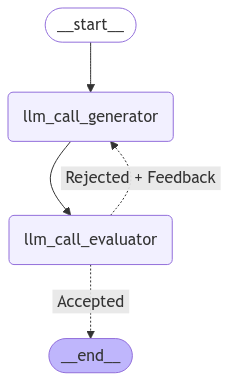

In [36]:
# Build workflow
optimizer_builder = StateGraph(State)

optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")

optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

optimizer_builder = optimizer_builder.compile()

display(Image(optimizer_builder.get_graph().draw_mermaid_png()))

In [37]:
state = optimizer_builder.invoke({"topic": "fried chieken"})
print(state["joke"])

Here's a joke about fried chicken:

Why did the fried chicken cross the playground?

To get to the other slide! 

(A play on "other side" and the fact that fried chicken is slippery/greasy)


# AGENT

In [8]:
from langchain_core.tools import tool

# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [12]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_core.messages import ToolMessage
from typing import Literal

# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call

def should_continue(state: MessagesState) -> Literal["environment", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we stop (reply to the user)
    return END

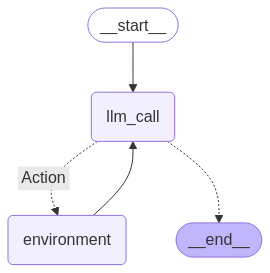

In [13]:
from IPython.display import Image, display

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        # Name returned by should_continue : Name of next node to visit
        "Action": "environment",
        END: END,
    },
)
agent_builder.add_edge("environment", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [14]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================

[{'text': "I'll help you add 3 and 4 using the `add` function.", 'type': 'text'}, {'id': 'toolu_01PpcbHqYw2oX79SYVkZT4dY', 'input': {'a': 3, 'b': 4}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_01PpcbHqYw2oX79SYVkZT4dY)
 Call ID: toolu_01PpcbHqYw2oX79SYVkZT4dY
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


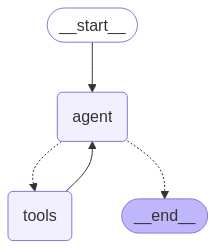

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================

[{'text': "I'll help you add 3 and 4 using the `add` function.", 'type': 'text'}, {'id': 'toolu_01PpSgMQ2QL8j5daJC2hEcoY', 'input': {'a': 3, 'b': 4}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_01PpSgMQ2QL8j5daJC2hEcoY)
 Call ID: toolu_01PpSgMQ2QL8j5daJC2hEcoY
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [15]:
from langgraph.prebuilt import create_react_agent

# Pass in:
# (1) the augmented LLM with tools
# (2) the tools list (which is used to create the tool node)
pre_built_agent = create_react_agent(llm, tools=tools)

# Show the agent
display(Image(pre_built_agent.get_graph().draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = pre_built_agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()